<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
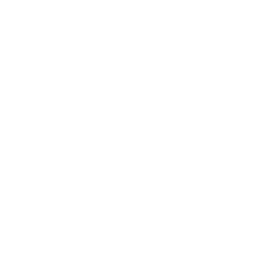
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Smart Meter Load Shape Pattern Extraction</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energy / Demand-Side Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Smart-meter rollouts produce a 24-hour electricity-consumption curve for every household. Pricing and demand-response teams need to compress those 24 correlated readings into a few interpretable load-shape factors and then group customers by shape. This worked example applies **PROC PRINCOMP** to the hourly profiles, then feeds the leading component scores into **PROC FASTCLUS** to segment the customers.

On the 100 residential profiles analyzed here, the first principal component captures **64.2%** of the variance and the second a further **27.8%**, so a two-dimensional load-shape space already explains **92.0%** of the variation between households; the first four components reach **96.5%**. Every hour loads positively on PC1, marking it as an overall-consumption-level axis, while PC2 contrasts overnight hours against the morning/evening shoulders — a *timing* axis. Clustering the component scores into four groups yields a pseudo-F statistic of **213.5** and an overall R-squared of **0.870**. The four segments range from a low-use group averaging **13.0 kWh/day** to a high-baseload group averaging **30.8 kWh/day**, providing a ready-made target list for time-of-use rate design and demand-response recruitment.


## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.LOAD_PROFILES | Average hourly kWh consumption per customer, `hour_0`-`hour_23` (24 columns), plus daily total and peak-hour load | 100 |

The DATA step synthesizes four residential archetypes - commuters with morning and evening peaks, work-from-home customers with an elevated midday plateau, shift workers with overnight-heavy usage, and high-baseload electric-heating homes. This run executes in unlicensed mode, which caps the analytic sample at 100 customers; the same code scales unchanged to a full meter population.


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic 24-hour load profiles
   Mix of residential archetypes:
     - Morning/evening peakers (commuters)
     - Daytime flat (work-from-home)
     - Night-heavy (shift workers)
     - High-baseload (electric heating)
   -------------------------------------------------------- */
data work.load_profiles;
    call streaminit(42);
    length customer_id $12 rate_class $15 region $12;
    array hr[24] hour_0-hour_23;
    array regions[4] $12 _temporary_ ('NORTH' 'SOUTH' 'EAST' 'WEST');

    do cust_num = 1 to 5000;
        customer_id = cat('SM-', put(cust_num, z6.));
        reg_idx = int(rand('uniform') * 4) + 1;
        region = regions[reg_idx];

        /* Assign archetype */
        archetype = int(rand('uniform') * 4) + 1;
        select(archetype);
            when(1) rate_class = 'COMMUTER';
            when(2) rate_class = 'WFH';
            when(3) rate_class = 'SHIFT_WORKER';
            when(4) rate_class = 'HIGH_BASELOAD';
        end;

        /* Base load by archetype */
        base = rand('uniform') * 0.3 + 0.2;
        scale = rand('uniform') * 0.8 + 0.5;

        do h = 0 to 23;
            select(archetype);
                when(1) do;
                    /* Morning + evening peaks */
                    peak = scale * (exp(-((h-7)**2)/4) + 1.2*exp(-((h-19)**2)/6));
                    hr[h+1] = round(base + peak + rand('normal', 0, 0.08), 0.001);
                end;
                when(2) do;
                    /* Elevated daytime plateau */
                    peak = scale * (0.6 + 0.4*exp(-((h-13)**2)/20));
                    hr[h+1] = round(base + peak + rand('normal', 0, 0.06), 0.001);
                end;
                when(3) do;
                    /* Night-heavy usage */
                    peak = scale * (0.8*exp(-((h-2)**2)/8) + 0.3*exp(-((h-14)**2)/4));
                    hr[h+1] = round(base + peak + rand('normal', 0, 0.07), 0.001);
                end;
                when(4) do;
                    /* High flat baseload with slight evening bump */
                    peak = scale * (0.8 + 0.3*exp(-((h-20)**2)/8));
                    hr[h+1] = round(base + peak + rand('normal', 0, 0.1), 0.001);
                end;
            end;
            if hr[h+1] < 0.01 then hr[h+1] = 0.01;
        end;

        avg_daily_kwh = round(sum(of hour_0-hour_23), 0.01);
        peak_hour_kwh = max(of hour_0-hour_23);

        drop cust_num reg_idx archetype base scale peak h;
        output;
    end;
run;

NOTE: DATA work.load_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.load_profiles (100 rows, 29 columns).
NOTE: DATA elapsed:
  wall  1.90 seconds
  cpu   1.90 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline average load profile by rate class
   -------------------------------------------------------- */
proc means data=work.load_profiles mean;
    class rate_class;
    var hour_0 hour_6 hour_12 hour_18 hour_23 avg_daily_kwh;
    title 'Average Hourly Consumption by Customer Archetype';
run;

                                    Average Hourly Consumption by Customer Archetype                                    

                                                  The MEANS Procedure

                                               Analysis Variable : HOUR_0

                                   N
        RATE_CLASS               Obs           Mean
        -------------------------------------------
        COMMUTER                  28      0.3498571
        HIGH_BASELOAD             27      1.0421111
        SHIFT_WORKER              23      0.8002174
        WFH                       22      0.9574091
        -------------------------------------------

                                               Analysis Variable : HOUR_6

                                   N
        RATE_CLASS               Obs           Mean
        -------------------------------------------
        COMMUTER                  28      1.0220000
        HIGH_BASELOAD             27      1.0614444
        SH

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                    Average Hourly Consumption by Customer Archetype                                    



NOTE: PROC MEANS
NOTE: Output dataset work.mean_profiles has 5 observations and 27 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.mean_profiles_long


NOTE: Read 5 rows from work.mean_profiles.
NOTE: Wrote work.mean_profiles_long (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.mean_profiles_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


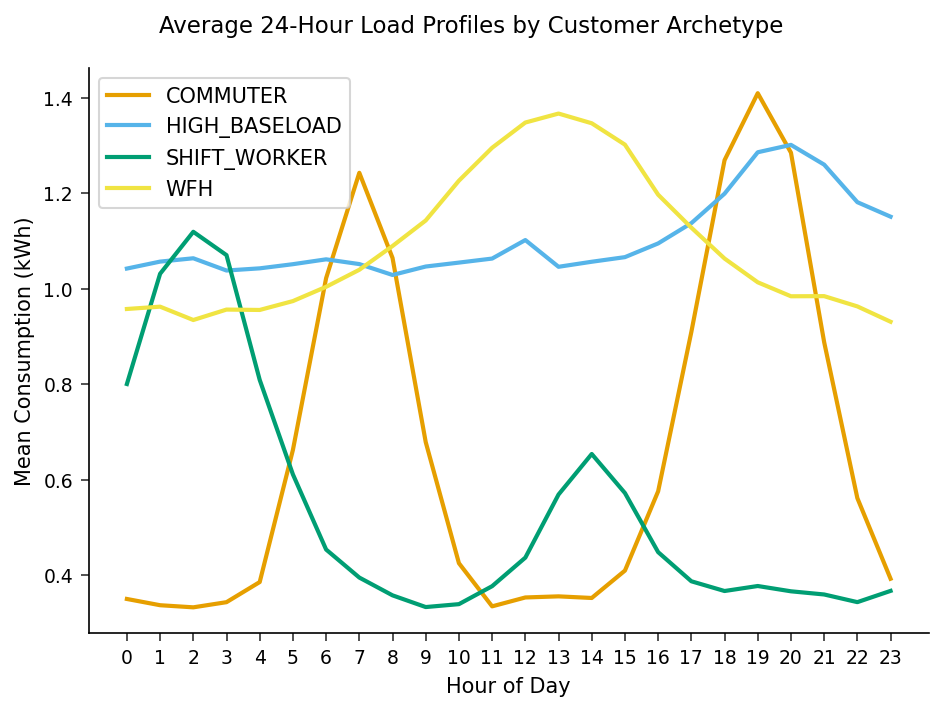

In [3]:
/* --------------------------------------------------------
   Overlay mean load curves by rate class
   -------------------------------------------------------- */
proc means data=work.load_profiles noprint;
    class rate_class;
    var hour_0-hour_23;
    output out=work.mean_profiles mean=;
run;

data work.mean_profiles_long;
    set work.mean_profiles(where=(_type_=1));
    array hr[24] hour_0-hour_23;
    do hour = 0 to 23;
        mean_kwh = hr[hour+1];
        output;
    end;
    keep rate_class hour mean_kwh;
run;

proc sgplot data=work.mean_profiles_long;
    series x=hour y=mean_kwh / group=rate_class lineattrs=(thickness=2);
    xaxis label='Hour of Day' integer values=(0 to 23);
    yaxis label='Mean Consumption (kWh)';
    title 'Average 24-Hour Load Profiles by Customer Archetype';
run;

---

                                    Average Hourly Consumption by Customer Archetype                                    

                       The PRINCOMP Procedure

                    Observations         100
                    Variables             24

                       Simple Statistics

Variable            Mean          StdDev

hour_0           0.77401         0.32937
hour_1           0.82846         0.34714
hour_2           0.84319         0.37563
hour_3           0.83285         0.35829
hour_4           0.78559         0.31264
hour_5           0.82399         0.25498
hour_6           0.89789         0.29988
hour_7           0.95135         0.38364
hour_8           0.89765         0.36064
hour_9           0.80050         0.37013
hour_10          0.75142         0.41849
hour_11          0.75222         0.45464
hour_12          0.79330         0.47062
hour_13          0.81336         0.44669
hour_14          0.83032         0.42746
hour_15          0.82033         0.40620


NOTE: PROC PRINCOMP data=work.load_profiles

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   Prin1: Eigenvalue=15.408860  Proportion=0.6420  Cumulative=0.6420
NOTE:   Prin2: Eigenvalue=6.676920  Proportion=0.2782  Cumulative=0.9202
NOTE:   Prin3: Eigenvalue=0.808711  Proportion=0.0337  Cumulative=0.9539
NOTE:   Prin4: Eigenvalue=0.271243  Proportion=0.0113  Cumulative=0.9652
NOTE:   Prin5: Eigenvalue=0.089324  Proportion=0.0037  Cumulative=0.9690
NOTE:   Prin6: Eigenvalue=0.081315  Proportion=0.0034  Cumulative=0.9723
NOTE:   Prin7: Eigenvalue=0.071436  Proportion=0.0030  Cumulative=0.9753
NOTE:   Prin8: Eigenvalue=0.062822  Proportion=0.0026  Cumulative=0.9779
NOTE:   Prin9: Eigenvalue=0.058066  Proportion=0.0024  Cumulative=0.9804
NOTE:   Prin10: Eigenvalue=0.054595  Proportion=0.0023  Cumulative=0.9826
NOTE:   Prin11: Eigenvalue=0.053454  Proportion=0.0022  Cumulative=0.9849
NOTE:   Prin12: Eigenvalue=0.049832  Proportion=0.0021  Cumulat

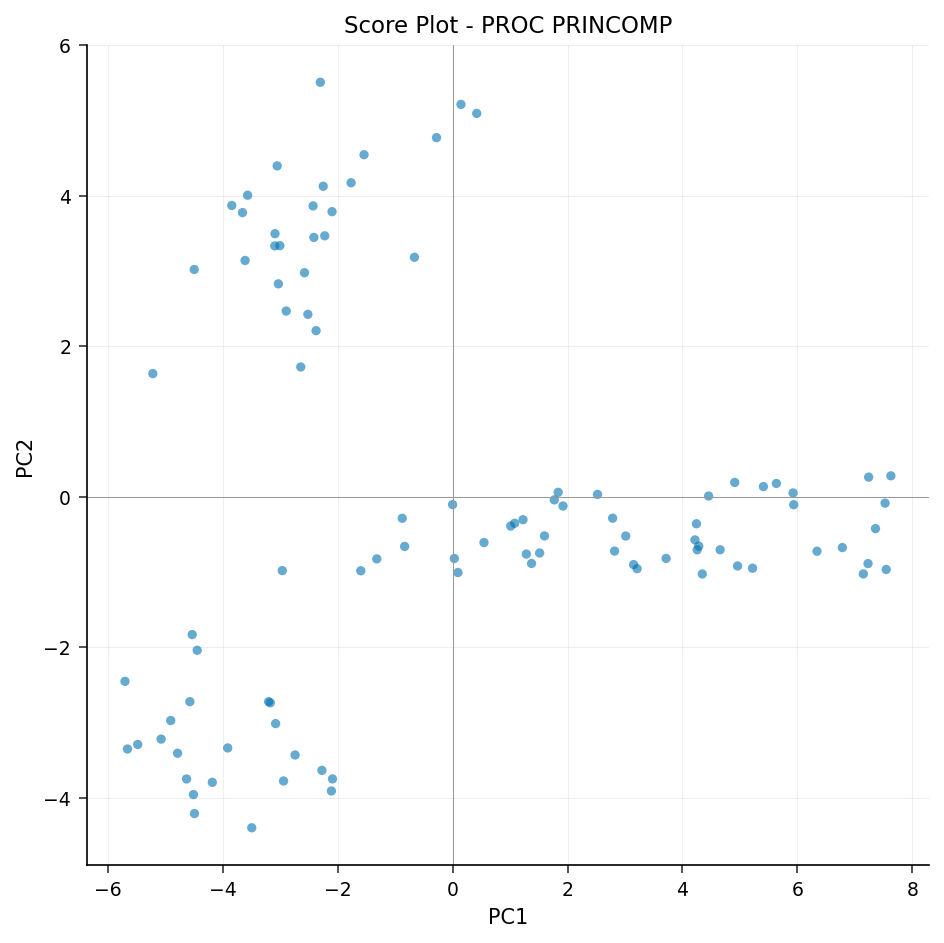

In [4]:
/* --------------------------------------------------------
   PCA on 24-hour load profiles
   SCORE plot for visual cluster identification
   -------------------------------------------------------- */
proc princomp data=work.load_profiles
    out=work.load_scores
    plots=(scree score);
    var hour_0-hour_23;
    title 'PCA on 24-Hour Smart Meter Load Profiles';
run;

In [5]:
/* --------------------------------------------------------
   Feed first 4 PCs into PROC FASTCLUS
   to segment customers into load shape clusters
   -------------------------------------------------------- */
proc fastclus data=work.load_scores
    out=work.load_clusters
    maxclusters=4
    maxiter=50;
    var Prin1 Prin2 Prin3 Prin4;
    title 'K-Means Clustering on Principal Component Scores';
run;

                                    Average Hourly Consumption by Customer Archetype                                    


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  24         0.8944             3.0638              4         4.6074
2                  28         0.8674             3.6877              1         5.5648
3                  24         0.7893             3.1903              1         5.8778
4

NOTE: PROC FASTCLUS data=work.load_scores maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 4 variables, 4 clusters using k-means


In [6]:
/* --------------------------------------------------------
   Profile clusters: mean consumption and peak hour
   -------------------------------------------------------- */
proc means data=work.load_clusters n mean;
    class cluster;
    var avg_daily_kwh peak_hour_kwh Prin1 Prin2;
    title 'Cluster Profiles: Consumption and PC Scores';
run;

                                      Cluster Profiles: Consumption and PC Scores                                       

                                                  The MEANS Procedure

                                           Analysis Variable : AVG_DAILY_KWH

        CLUSTER           N Obs           Mean
        --------------------------------------
        1                    24     22.3500000
        2                    28     15.9360714
        3                    24     13.0020833
        4                    24     30.8191667
        --------------------------------------

                                           Analysis Variable : PEAK_HOUR_KWH

        CLUSTER           N Obs           Mean
        --------------------------------------
        1                    24      1.2070000
        2                    28      1.4210714
        3                    24      1.1297917
        4                    24      1.6090417
        -------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretation

**Two components describe the load-shape space.** The eigenvalues of the correlation matrix fall away sharply after the second component: PC1 = 15.41 (64.2% of variance) and PC2 = 6.68 (27.8%), together **92.0%**. PC3 and PC4 add only 3.4% and 1.1%, bringing the first four components to **96.5%** cumulative. The scree pattern - two dominant components and a long low flat tail - confirms that 24 hourly readings collapse to essentially two load-shape factors.

**What the components mean.** Every one of the 24 hours loads *positively* on PC1 (loadings 0.12-0.25), so PC1 is an overall-magnitude axis: a high PC1 score means a high-consumption household across the whole day. PC2 separates timing: the overnight hours (`hour_0`-`hour_4`) carry negative loadings near -0.23 to -0.31 while the morning and evening shoulders (`hour_6`-`hour_8`, `hour_18`-`hour_20`) carry positive loadings near +0.24 to +0.32. A high PC2 score therefore marks a customer whose demand is concentrated in the commuting peaks rather than overnight.

**The score plot shows the structure PROC FASTCLUS then formalizes.** In the PC1-PC2 plane the points fall into a high-PC2 cloud (upper region), a low-PC1/low-PC2 cloud (lower-left), a high-PC1 cloud (right), and a group near the origin. Running k-means on the first four component scores produces a four-cluster solution with **pseudo-F = 213.5** and **overall R-squared = 0.870** - PC1 and PC2 alone account for R-squared of 0.892 and 0.924 within the clustering, confirming the segmentation rests on the two load-shape factors rather than noise.

**The four segments, profiled on their real consumption:**

| Cluster | Customers | Avg daily kWh | Peak-hour kWh | Mean PC1 | Mean PC2 | Reading |
|--------:|----------:|--------------:|--------------:|---------:|---------:|---------|
| 4 | 24 | **30.82** | 1.61 | **+5.71** | -0.44 | High-baseload / heavy users - highest daily energy and the largest PC1 score |
| 1 | 24 | 22.35 | 1.21 | +1.17 | -0.53 | Moderate, mildly overnight-leaning users |
| 2 | 28 | 15.94 | 1.42 | -2.50 | **+3.57** | Peaky timing - the highest PC2 group, demand concentrated in morning/evening shoulders |
| 3 | 24 | **13.00** | 1.13 | -3.96 | -3.20 | Lowest-consumption households |

**So what.** Cluster 4 (24 of 100 customers, ~31 kWh/day) carries the most energy and the highest peak-hour draw - the natural recruitment pool for demand-response events at system peak. Cluster 2 (28 customers) has the spikiest *timing* despite only modest daily totals, making it the best fit for a time-of-use tariff that rewards shifting load off the morning and evening shoulders. Cluster 3 anchors the low-consumption end and is a poor return on either program. Because the segmentation is built from interpretable principal-component scores rather than raw hourly columns, each customer's cluster assignment comes with a transparent reason - level (PC1) and timing (PC2) - that can be carried straight into rate-design and outreach decisions.

*Note: principal-component direction is read from the `OUT=` scores (the `Prin1`/`Prin2` cluster means above), which are the values the clustering and the score plot use.*


---

In [7]:
/* --------------------------------------------------------
   Export cluster assignments for CRM integration
   -------------------------------------------------------- */
proc export data=work.load_clusters(keep=customer_id region rate_class
    cluster avg_daily_kwh peak_hour_kwh Prin1 Prin2)
    outfile='smart_meter_load_clusters.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.load_clusters outfile=smart_meter_load_clusters.csv

NOTE: Exported 100 rows to smart_meter_load_clusters.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>